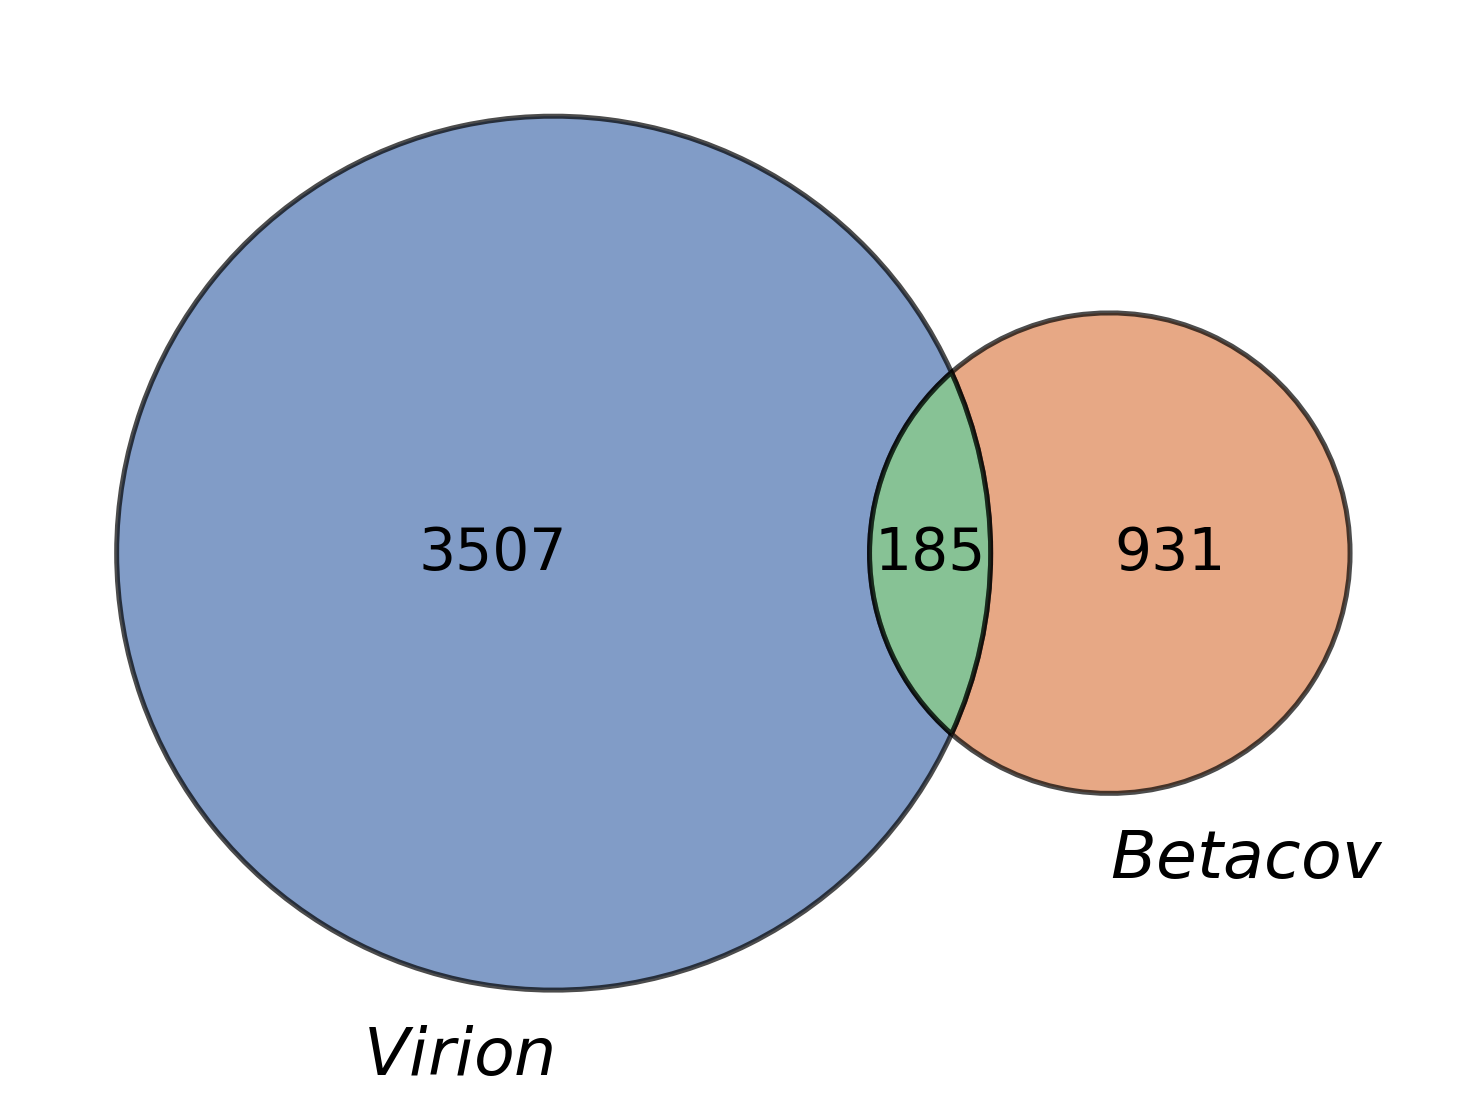

In [5]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# --- Data ---
virion_hosts = 3692
betacov_hosts = 1116
common_hosts = 185

# --- Create figure ---
plt.figure(figsize=(5,5), dpi=300)

venn = venn2(
    subsets=(virion_hosts - common_hosts, betacov_hosts - common_hosts, common_hosts),
    set_labels=(r"$\it{Virion}$", r"$\it{Betacov}$")  # italic labels
)

# --- Style circles ---
colors = ["#4C72B0", "#DD8452", "#55A868"]  # subtle, color-blind-safe palette
venn.get_patch_by_id('10').set_color(colors[0])
venn.get_patch_by_id('01').set_color(colors[1])
venn.get_patch_by_id('11').set_color(colors[2])
for region in ['10', '01', '11']:
    if venn.get_patch_by_id(region):
        venn.get_patch_by_id(region).set_alpha(0.7)
        venn.get_patch_by_id(region).set_edgecolor("black")
        venn.get_patch_by_id(region).set_linewidth(1.2)

# --- Style labels ---
for text in venn.set_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')
for text in venn.subset_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('medium')

# --- Final touches ---
# plt.title("Host Overlap between Virion and Betacov", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("venn_virion_betacov.svg", bbox_inches='tight')
plt.show()


Hosts from CSV: 24


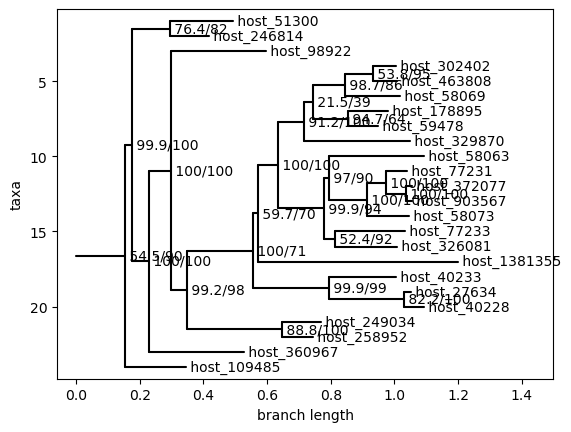

In [3]:
from Bio import Phylo
import pandas as pd
from io import StringIO

# ---- Load data ----
csv_file = "flipped_matrix_fn_hosts.csv"
tree_file = "virion_bat_cov_output/trees/hosts_tree.newick"

# Read CSV and get row/column names
df = pd.read_csv(csv_file, index_col=0)
host_names = df.columns.tolist()  # since your example has host_* in columns
print(f"Hosts from CSV: {len(host_names)}")

# ---- Read Newick tree ----
tree = Phylo.read(tree_file, "newick")

# ---- Prune tree ----
# Keep only the hosts found in the CSV (intersection of both sets)
all_tree_names = {term.name for term in tree.get_terminals()}
hosts_in_tree = [h for h in host_names if h in all_tree_names]

# Create a copy of the tree and prune
subtree = tree
for leaf in all_tree_names - set(hosts_in_tree):
    subtree.prune(leaf)

# ---- Sort tips in CSV order ----
# Biopython trees don't enforce tip order by default, so we can reorder when plotting or exporting
ordered_clades = [subtree.find_any(name=h) for h in hosts_in_tree]

# ---- Optional: write new tree ----
Phylo.write(subtree, "subtree.nwk", "newick")

# ---- Plot (optional) ----
import matplotlib.pyplot as plt
Phylo.draw(subtree, do_show=True)

In [4]:
import pandas as pd

# --- Read your matrix ---
df = pd.read_csv("flipped_matrix_fn_hosts.csv", index_col=0)

# --- Define your desired order ---
virus_order = [
    "virus_1805463", "virus_3061635", "virus_3068888", "virus_2833184", "virus_864596",
    "virus_3418604", "virus_694009", "virus_3068538", "virus_3433764", "virus_989337",
    "virus_2833022", "virus_2913444", "virus_3418614", "virus_3418613", "virus_2913443",
    "virus_1335626", "virus_2832974", "virus_3433775", "virus_1928434", "virus_3433757",
    "virus_3418615", "virus_3433776"
]

host_order = [
    "host_372077", "host_903567", "host_77231", "host_58073", "host_58063", "host_77233",
    "host_326081", "host_302402", "host_463808", "host_58069", "host_178895", "host_59478",
    "host_329870", "host_1381355", "host_27634", "host_40228", "host_40233", "host_51300",
    "host_246814", "host_109485", "host_360967", "host_98922", "host_249034", "host_258952"
]

# --- Reorder safely (only keep names that exist in df) ---
df = df.loc[[v for v in virus_order if v in df.index],
            [h for h in host_order if h in df.columns]]

# --- Save reordered matrix ---
df.to_csv("flipped_matrix_reordered.csv")

print("✅ Reordered matrix saved as flipped_matrix_reordered.csv")
print(f"Matrix shape: {df.shape}")

✅ Reordered matrix saved as flipped_matrix_reordered.csv
Matrix shape: (22, 24)


In [6]:
import pandas as pd
from Bio import Phylo

# --- Input files ---
host_csv = "filtered_virus_taxonomy.csv"
tree_file = "virion_bat_cov_output/trees/viruses_tree_beta_only.newick"
output_file = "virus_tree_renamed.nwk"

# --- Step 1: Load host taxonomy ---
host_df = pd.read_csv(host_csv)

# Build mapping from VirusTaxID -> Capitalized Virus name
id_to_name = {
    str(row.VirusTaxID): row.Virus.capitalize().replace(" ", "_")
    for _, row in host_df.iterrows()
}

# --- Step 2: Read tree ---
tree = Phylo.read(tree_file, "newick")

# --- Step 3: Replace leaf names ---
for clade in tree.get_terminals():
    if clade.name and clade.name.startswith("virus_"):
        taxid = clade.name.replace("virus_", "")
        if taxid in id_to_name:
            clade.name = id_to_name[taxid]
            # remove apostrophes if any
            clade.name = clade.name.replace("'", "")
        else:
            print(f"Warning: TaxID {taxid} not found in CSV")

# --- Step 4: Write new tree ---
Phylo.write(tree, output_file, "newick")
print(f"✅ Tree saved to {output_file}")


✅ Tree saved to virus_tree_renamed.nwk


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_matrix(mat, filename="matrix.png", highlight=None):
    """
    Plot binary virus–host matrix (no labels or ticks).
    
    highlight: dict with keys as category name and values as 
               list of (row_idx, col_idx) coordinates.
               Example:
               {
                   "corrupted": [(0,1), (3,2)],
                   "flipped": [(4,5)]
               }
    """
    fig, ax = plt.subplots(figsize=(mat.shape[1]*0.4, mat.shape[0]*0.4))

    # Copy matrix
    color_mat = np.copy(mat).astype(float)

    # Reserve codes for highlights
    code_map = {"corrupted": 2, "flipped": 3}
    if highlight is not None:
        for category, cells in highlight.items():
            if category not in code_map:
                continue
            for i, j in cells:
                color_mat[i, j] = code_map[category]

    # Colormap
    cmap = mcolors.ListedColormap(['lightgray', 'darkgreen', 'orange', 'red'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    ax.imshow(color_mat, cmap=cmap, norm=norm)

    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Optional: add thin gridlines
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close(fig)
    print(f"Matrix saved as {filename}")


# --- Usage example ---
# Read your CSV
df = pd.read_csv("flipped_matrix_reordered_del_dup.csv", index_col=0)

# Extract the numeric part
mat = df.values

# Plot without labels
plot_matrix(mat, filename="flipped_matrix_highlighted.svg")

Matrix saved as flipped_matrix_highlighted.svg
